# 12. Comparación de nubes de puntos para la mejor configuración

Este notebook presenta comparaciones en vista BEV de nubes de puntos para una pareja de frames consecutivos.

Incluye:
1. pseudo-LiDAR frontal base antes y después del registro `cfg_05`,
2. LiDAR GT antes y después del registro,
3. comparación entre las dos variantes frontales sobre la misma pareja.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
BASE_DIR = Path('/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061')
run_summary = json.loads((BASE_DIR / 'run_summary.json').read_text())
comparison = json.loads((BASE_DIR / 'front_best_combination.json').read_text())

PAIR_INDEX = 0
PLOT_XLIM = (-5, 18)
PLOT_YLIM = (-6, 6)

samples = sorted(run_summary['samples'], key=lambda x: x['index'])
src_meta = samples[PAIR_INDEX]
tgt_meta = samples[PAIR_INDEX + 1]
pair_result = comparison['pairs'][PAIR_INDEX]
pair_result


{'pair_index': 0,
 'source_token': 'ca9a282c9e77460f8360f564131a8af5',
 'target_token': '39586f9d59004284a7114a68825e8eec',
 'strategies': {'front_baseline_cfg05': {'num_source_points': 6987,
   'num_target_points': 6671,
   'metrics': {'fitness': 0.779,
    'rmse': 0.6481790787047539,
    'translation_error_m': 1.062414467411657,
    'rotation_error_deg': 0.9658839335236121}},
  'front_narrow_cfg05': {'num_source_points': 5427,
   'num_target_points': 5589,
   'metrics': {'fitness': 0.7540407589599438,
    'rmse': 0.6021375688950824,
    'translation_error_m': 0.2943832648625366,
    'rotation_error_deg': 1.0274957052245284}}}}

In [3]:
def load_points(path):
    pcd = o3d.io.read_point_cloud(str(path))
    return np.asarray(pcd.points, dtype=np.float64)


def select_front_baseline(points):
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    r = np.linalg.norm(points[:, :3], axis=1)
    mask = (r >= 2.0) & (r <= 35.0) & (z >= -2.0) & (z <= 2.5)
    mask &= (x > 0.0) & (np.abs(y) < 15.0)
    return points[mask]


def select_front_narrow(points):
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    r = np.linalg.norm(points[:, :3], axis=1)
    mask = (r >= 2.0) & (r <= 35.0) & (z >= -2.0) & (z <= 2.5)
    mask &= (x > 0.0) & (np.abs(y) < 10.0)
    return points[mask]


def apply_transform(points, transform):
    points_h = np.concatenate([points, np.ones((points.shape[0], 1), dtype=np.float64)], axis=1)
    return (transform @ points_h.T).T[:, :3]


def plot_bev_overlay(ax, a, b, title, label_a='source', label_b='target'):
    ax.scatter(a[:, 0], a[:, 1], s=3, alpha=0.35, label=label_a)
    ax.scatter(b[:, 0], b[:, 1], s=3, alpha=0.35, label=label_b)
    ax.set_title(title)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_xlim(*PLOT_XLIM)
    ax.set_ylim(*PLOT_YLIM)
    ax.grid(True, alpha=0.25)
    ax.axis('equal')
    ax.legend(markerscale=4)


In [4]:
src_pseudo_all = load_points(Path(src_meta['pseudo_path']))
tgt_pseudo_all = load_points(Path(tgt_meta['pseudo_path']))
src_gt_all = load_points(Path(src_meta['lidar_path']))
tgt_gt_all = load_points(Path(tgt_meta['lidar_path']))

src_front_base = select_front_baseline(src_pseudo_all)
tgt_front_base = select_front_baseline(tgt_pseudo_all)
src_front_narrow = select_front_narrow(src_pseudo_all)
tgt_front_narrow = select_front_narrow(tgt_pseudo_all)

base_transform = np.array(pair_result['strategies']['front_baseline_cfg05']['estimated_transform']) if 'estimated_transform' in pair_result['strategies']['front_baseline_cfg05'] else None
narrow_transform = np.array(pair_result['strategies']['front_narrow_cfg05']['estimated_transform']) if 'estimated_transform' in pair_result['strategies']['front_narrow_cfg05'] else None


In [5]:
traj = json.loads((BASE_DIR / 'accumulated_trajectory_comparison.json').read_text())
base_transform = np.array(traj['pairwise_results']['front_baseline_cfg05'][PAIR_INDEX]['estimated_transform'])
narrow_transform = np.array(traj['pairwise_results']['front_narrow_cfg05'][PAIR_INDEX]['estimated_transform'])

src_front_base_aligned = apply_transform(src_front_base, base_transform)
src_front_narrow_aligned = apply_transform(src_front_narrow, narrow_transform)


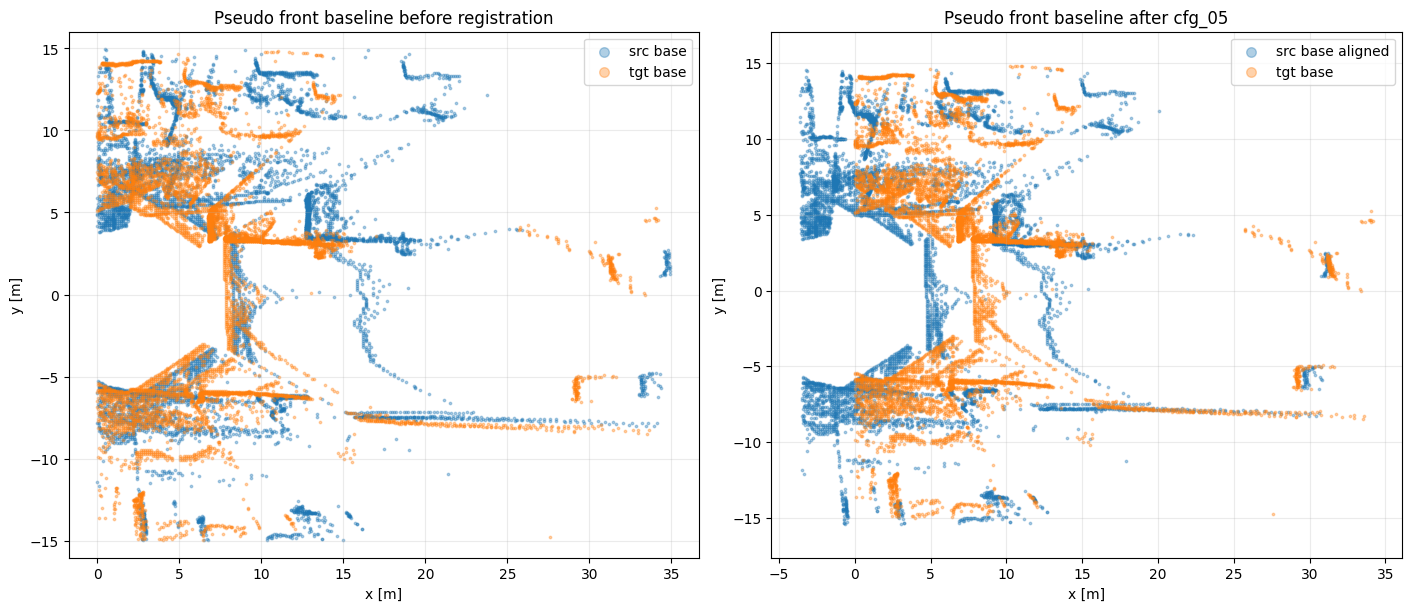

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
plot_bev_overlay(axes[0], src_front_base, tgt_front_base, 'Pseudo front baseline before registration', 'src base', 'tgt base')
plot_bev_overlay(axes[1], src_front_base_aligned, tgt_front_base, 'Pseudo front baseline after cfg_05', 'src base aligned', 'tgt base')
plt.show()


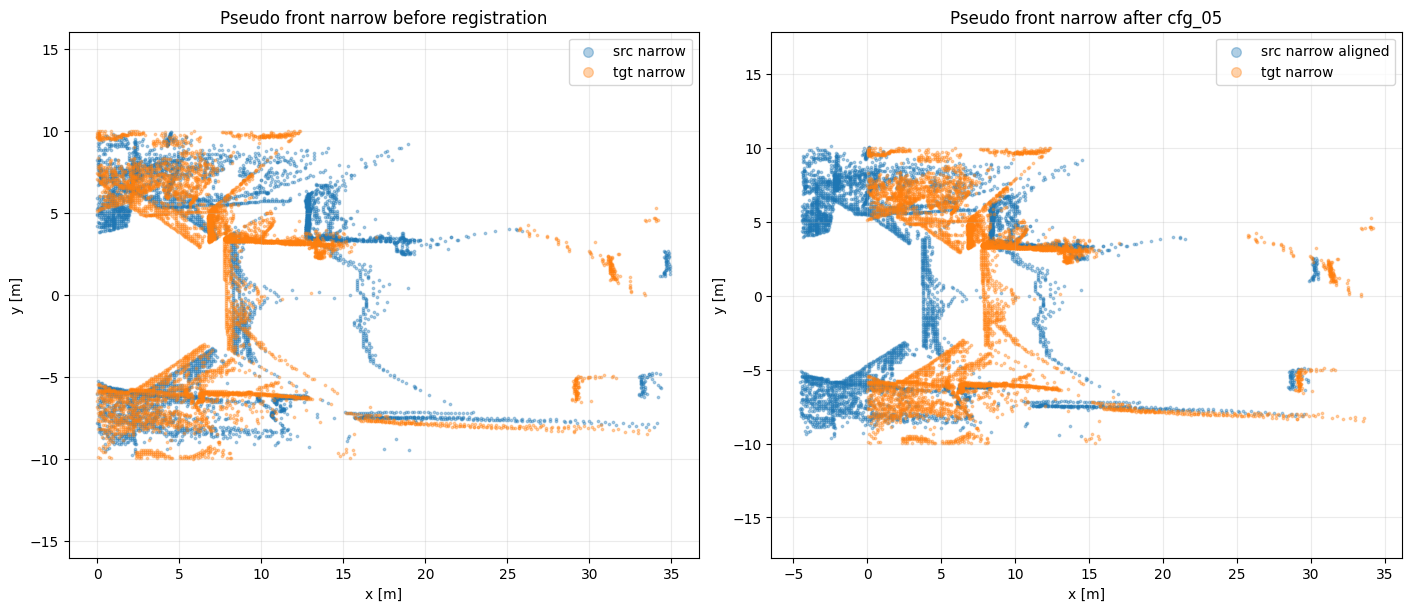

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
plot_bev_overlay(axes[0], src_front_narrow, tgt_front_narrow, 'Pseudo front narrow before registration', 'src narrow', 'tgt narrow')
plot_bev_overlay(axes[1], src_front_narrow_aligned, tgt_front_narrow, 'Pseudo front narrow after cfg_05', 'src narrow aligned', 'tgt narrow')
plt.show()


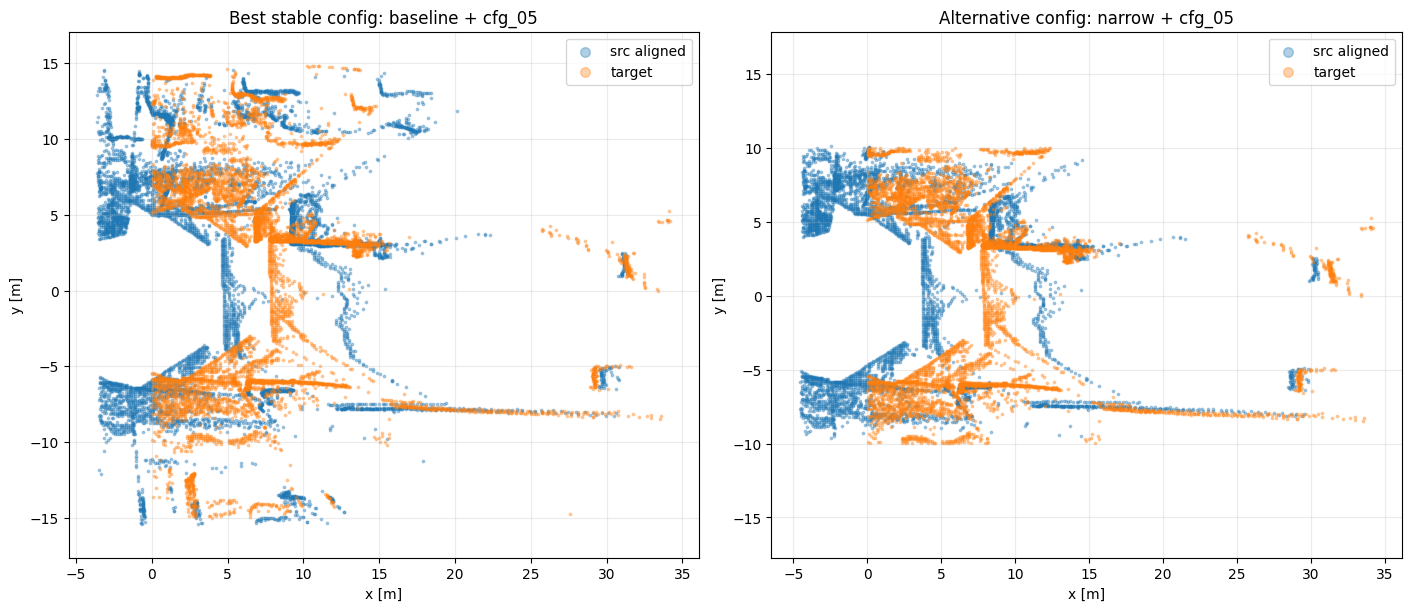

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
plot_bev_overlay(axes[0], src_front_base_aligned, tgt_front_base, 'Best stable config: baseline + cfg_05', 'src aligned', 'target')
plot_bev_overlay(axes[1], src_front_narrow_aligned, tgt_front_narrow, 'Alternative config: narrow + cfg_05', 'src aligned', 'target')
plt.show()


In [9]:
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
plot_bev_overlay(ax, src_front_base_aligned, tgt_front_base, 'Best stable config: baseline + cfg_05', 'src aligned', 'target')
fig.savefig(BASE_DIR / 'pointcloud_comparison_best_cfg05.png', dpi=160)
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
plot_bev_overlay(ax, src_front_narrow_aligned, tgt_front_narrow, 'Alternative config: narrow + cfg_05', 'src aligned', 'target')
fig.savefig(BASE_DIR / 'pointcloud_comparison_narrow_cfg05.png', dpi=160)
plt.close(fig)

print(BASE_DIR / 'pointcloud_comparison_best_cfg05.png')
print(BASE_DIR / 'pointcloud_comparison_narrow_cfg05.png')


/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/pointcloud_comparison_best_cfg05.png
/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/pointcloud_comparison_narrow_cfg05.png


## Lectura rápida

- La primera fila permite comprobar si el registro mejora visualmente el encaje de la nube frontal base.
- La segunda fila muestra el comportamiento de la variante frontal estrecha.
- La comparación final ayuda a explicar por qué una estrategia puede parecer mejor localmente y, sin embargo, derivar más al acumular transformaciones.


## Conclusiones de la comparación

- Antes del registro existe un desfase claro entre `src` y `target` en ambas configuraciones.
- Después de aplicar `cfg_05`, tanto `front_baseline` como `front_narrow` mejoran de forma visible su encaje.
- `front_narrow_cfg05` ajusta mejor algunas parejas concretas y puede presentar una apariencia más compacta en el plano local.
- `front_baseline_cfg05` conserva mejor la estructura global y resulta más estable cuando las transformaciones se acumulan a lo largo de la secuencia.
- Por ello, para comparación frame a frame ambas variantes son válidas, pero para una lectura más próxima a SLAM la configuración recomendada sigue siendo `front_baseline_cfg05`.


## Visualizacion 3D complementaria

Ademas de la vista BEV, se añade una comparacion 3D interactiva de las fases principales de la nube. Esta visualizacion ayuda a inspeccionar la estructura espacial completa, incluyendo altura y dispersion.

Enlaces directos:

- [Nube densa, pseudo-LiDAR y LiDAR real](../outputs/scene-0061/pointcloud_phase_visualizations/phase_03_ring_pseudo_lidar_overlay.html)
- [Registro frontal despues de cfg_05](../outputs/scene-0061/pointcloud_phase_visualizations/phase_04b_front_pair_after_cfg05.html)


In [10]:
from IPython.display import IFrame, display, Markdown
VIS_DIR = BASE_DIR / 'pointcloud_phase_visualizations'
display(Markdown('[Abrir indice de visualizaciones 3D](' + str(VIS_DIR / 'index.html') + ')'))
display(IFrame(src=str(VIS_DIR / 'phase_03_ring_pseudo_lidar_overlay.html'), width='100%', height=720))
display(IFrame(src=str(VIS_DIR / 'phase_04b_front_pair_after_cfg05.html'), width='100%', height=720))


[Abrir indice de visualizaciones 3D](/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/pointcloud_phase_visualizations/index.html)